# Forecasting Assignment 1

## Part I: Imports, Load Data

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from panelsplit.cross_validation import PanelSplit
from panelsplit.application import cross_val_fit_predict
from sklearn.ensemble import RandomForestClassifier


In [19]:
df = pd.read_csv('../data/final_panel_data.csv')
df = df.loc[df['isocode'] != 'KOR'].copy()
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.set_index(['isocode', 'period']).sort_index()
print(df.shape)
df.head(3)
#tst


(6933, 30)


date  yield_10y  Competition and Sports  \
isocode period                                                 
AUS     201001 2010-01-01     5.5575                0.061398   
        201002 2010-02-01     5.4775                0.062448   
        201003 2010-03-01     5.6200                0.059424   

                Health and Education  Military Conflict  Politics  \
isocode period                                                      
AUS     201001              0.073588           0.019415  0.019441   
        201002              0.073145           0.020595  0.021634   
        201003              0.075694           0.019563  0.022156   

                Military Technology  National Development  Political Tensions  \
isocode period                                                                  
AUS     201001             0.031388              0.067876            0.110389   
        201002             0.036304              0.063547            0.114383   
        201003             0.035235              0.072683            0.113926   

                Judiciary and Abuses  ...        vix  brent_oil  \
isocode period                        ...                         
AUS     201001              0.090134  ...  24.620001  71.459999   
        201002              0.095505  ...  19.500000  77.589996   
        201003              0.100099  ...  17.590000  82.699997   

                credit_spread  inflation   fx_rate  ip  stock_index  \
isocode period                                                        
AUS     201001      33.675831        NaN  1.096781 NaN    100.00000   
        201002      34.042908        NaN  1.127445 NaN     92.23358   
        201003      34.778976        NaN  1.095715 NaN     99.37471   

                terms_of_trade  reserves       debt  
isocode period                                       
AUS     201001        1.000000  38864.08  19.242444  
        201002        1.023580  36759.20  19.242444  
        201003        1.059195  34988.19  19.242444  

[3 rows x 30 columns]

## Target Variable Engineering

We define a yield spike as any month where a country's 10-year bond yield is more than **25% above** its trailing 12-month mean (excluding the current period to prevent leakage).

**`dev_from_mean_12m`** = (`yield_10y[t]` − mean(`yield_10y[t-12 : t-1]`)) / mean(`yield_10y[t-12 : t-1]`)

From this we build three target variables:

- **`any`**: Binary flag — 1 if `dev_from_mean_12m > 0.25`, else 0. This is the current-period spike indicator.
- **`incidence`**: 1 if a spike occurs in **at least one** of the next h months, else 0. Computed as the rolling max of `any` over a window of size h, shifted back by h.
- **`onset`**: 1 if a **new** spike starts in the next h months, else 0. Identical to incidence but set to NaN when `any==1` (already spiking), since onset is only meaningful when entering a spike from a non-spike state.

We compute incidence and onset for horizon h = 12


In [53]:
DEV_12M_THRESHOLD = 0.25
HORIZONS = [12]

g = df.groupby(level='isocode')

# Trailing 12m mean excluding current period — shift(1) before rolling is the leakage guard
trailing_mean_12m = g['yield_10y'].transform(
    lambda s: s.shift(1).rolling(12, min_periods=6).mean()
)
df['trailing_mean_12m'] = trailing_mean_12m
df['dev_from_mean_12m'] = (df['yield_10y'] - trailing_mean_12m) / trailing_mean_12m

df[['yield_10y', 'trailing_mean_12m', 'dev_from_mean_12m']].reset_index().round(2)


,isocode,period,yield_10y,trailing_mean_12m,dev_from_mean_12m
0,AUS,201001,5.56,NaN,NaN
1,AUS,201002,5.48,NaN,NaN
2,AUS,201003,5.62,NaN,NaN
3,AUS,201004,5.80,NaN,NaN
4,AUS,201005,5.48,NaN,NaN
...,...,...,...,...,...
6928,ZAF,202408,10.70,11.78,-0.09
6929,ZAF,202409,10.30,11.70,-0.12
6930,ZAF,202410,10.46,11.55,-0.09
6931,ZAF,202411,10.37,11.39,-0.09


#### Uses FeatureEngineer class from workbook

In [49]:
class TargetEngineer():

  """
  Class to generate target variables for incidence and onset under a given horizon.

  Args
  ----

  df: pd.DataFrame
    Dataframe with at least columns that include [unit, time, y_col]

  unit: str
    Column that defines your unit. E.g. 'isocode'

  time: str
    Column that defines your time. E.g. 'period'

  y_col: str
    Column that defines your y variable. E.g. 'violence'
  """

  def __init__(self, df:pd.DataFrame, unit:str, time:str, y_col:str):

    self.df = df.copy()
    self.unit = unit
    self.time = time
    self.y_col = y_col

  def any(self, threshold:int):

    """
    Function to compute "any" variable.

    Args
    ----

    threshold: int
      Threshold to apply to self.y_col.

    Returns
    -------

    pd.DataFrame
      Dataframe with any variable.

    str
      Name of the any variable.
    """

    any_col = f"any{self.y_col}_th{threshold}"
    self.df[any_col] = (self.df[self.y_col] > threshold).astype(int)
    return self.df.copy(), any_col

  def incidence(self, threshold:int, horizon:int):

    """
    Function to compute incidence target variable based on the specific threshold and horizon.

    Args
    ----

    threshold: int
      Threshold to apply to self.y_col.

    horizon: int
      Forecasting horizon (assumes aggregated window).

    Returns
    -------

    pd.DataFrame
      Dataframe with y_col, any_col, and target_col.
    """

    #make the any variable
    df, any_col = self.any(threshold)

    #get the rolling max value of your any variable over the specified horizon
    any_col_max = f"{any_col}_max"
    df[any_col_max] = self.df.groupby(self.unit)[any_col]. \
            transform(lambda x: x.rolling(window=horizon, min_periods = horizon).max())

    #shift any_col_max by the specified horizon to get your incidence target variable
    target_col = f"inc_{any_col}_h{horizon}"
    df[target_col] = df.groupby(self.unit)[any_col_max].transform(lambda x: x.shift(-horizon))

    return df[[self.y_col, any_col, target_col]]

  def onset(self, threshold:int, horizon:int):

    """
    Function to compute onset target variable based on the specific threshold and horizon.

    Args
    ----

    threshold: int
      Threshold to apply to self.y_col.

    horizon: int
      Forecasting horizon (assumes aggregated window).

    Returns
    -------

    pd.DataFrame
      Dataframe with y_col, any_col, and target_col.
    """

    #make the any variable
    df, any_col = self.any(threshold)

    def _onset(x:pd.Series, h:int):

      """
      Function to compute onset target variable for a single unit

      Args
      ---

      x: pd.Series
        The "any" variable for a single unit.

      h: int
        Forecasting horizon (assumes aggregated window).

      Returns
      -------

      pd.Series
        The onset target variable for a single unit.
      """

      index = x.index #get the index
      x = list(x) #convert to list
      y = [] #empty list for storing the onset target
      for i in range(len(x)): #iterate over every element in x
          i0 = i+1 #index of the next period
          i1 = i0+h #index at the end of the forecast horizon
          if i1 <= len(x) and x[i]==0: #first if condition is to handle the last h observations. Second condition states if any==0.
              y.append(np.max(x[i0:i1])) #append the max of the any column in the next h periods, assuming any==0 currently
          else:
              y.append(np.nan) #otherwise append NA
      return pd.Series(y, index)

    target_col = f"ons_{any_col}_h{horizon}"
    df[target_col] = self.df.groupby(self.unit)[any_col].transform(lambda x: _onset(x, horizon))

    return df[[self.y_col, any_col, target_col]]

In [50]:
# Step 1: any — is the current period a spike?
df['any'] = (df['dev_from_mean_12m'] > DEV_12M_THRESHOLD).astype(int)
df.loc[df['dev_from_mean_12m'].isna(), 'any'] = np.nan

# Step 2: incidence — does a spike occur in the next h months?
# (1 if any==1 in at least one of the next h periods)
for h in HORIZONS:
    df[f'inc_h{h}'] = (
        g['any']
        .transform(lambda s, h=h: s.rolling(h, min_periods=h).max().shift(-h))
    )

# Step 3: onset — does a NEW spike start in the next h months, given any==0 now?
# NaN if currently spiking (any==1), else max of any over next h periods
for h in HORIZONS:
    def _onset(s, h=h):
        rolled = s.rolling(h, min_periods=h).max().shift(-h)
        rolled[s == 1] = np.nan  # undefined when already spiking
        return rolled
    df[f'ons_h{h}'] = g['any'].transform(_onset)

# Sanity check
print("any rate:  ", df['any'].mean().round(3))
for h in HORIZONS:
    print(f"  inc_h{h}: {df[f'inc_h{h}'].mean().round(3)}  |  ons_h{h}: {df[f'ons_h{h}'].mean().round(3)}")


any rate:   0.096
  inc_h12: 0.252  |  ons_h12: 0.177


In [23]:
cols = ['yield_10y', 'trailing_mean_12m', 'dev_from_mean_12m', 'any']

inc_cols = ['inc_h12']
ons_cols = ['ons_h12']


### Table of incidence with different horizons


In [51]:
inc_display = df[cols + inc_cols].reset_index().round(2)
inc_display

,isocode,period,yield_10y,trailing_mean_12m,dev_from_mean_12m,any,inc_h12
0,AUS,201001,5.56,NaN,NaN,NaN,NaN
1,AUS,201002,5.48,NaN,NaN,NaN,NaN
2,AUS,201003,5.62,NaN,NaN,NaN,NaN
3,AUS,201004,5.80,NaN,NaN,NaN,NaN
4,AUS,201005,5.48,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
6928,ZAF,202408,10.70,11.78,-0.09,0.0,NaN
6929,ZAF,202409,10.30,11.70,-0.12,0.0,NaN
6930,ZAF,202410,10.46,11.55,-0.09,0.0,NaN
6931,ZAF,202411,10.37,11.39,-0.09,0.0,NaN


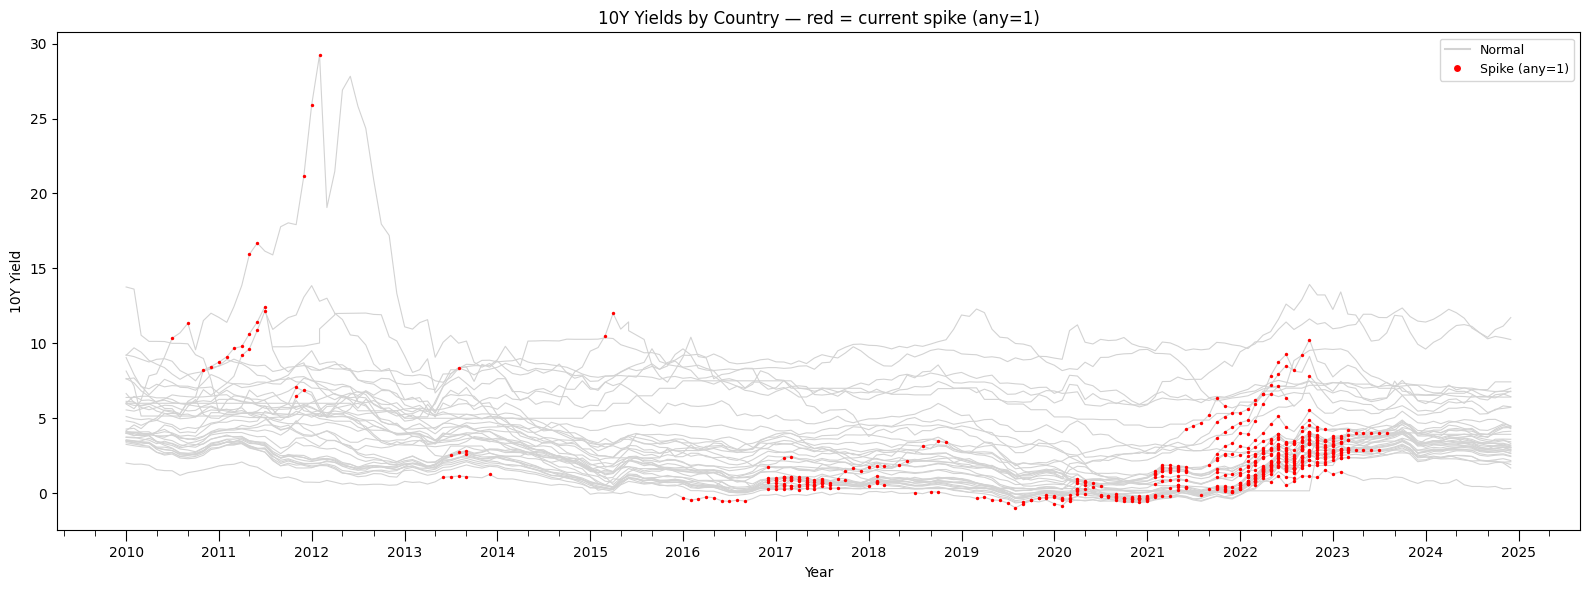

In [58]:
fig, ax = plt.subplots(figsize=(16, 6))

for isocode, group in df.groupby(level='isocode'):
    periods = group.index.get_level_values('period')
    dates = pd.to_datetime(periods.astype(str), format='%Y%m')
    yields = group['yield_10y']

    ax.plot(dates, yields, color='lightgrey', linewidth=0.8, zorder=1)

    mask = group['any'] == 1
    ax.scatter(dates[mask], yields[mask], color='red', s=6, zorder=2, linewidths=0)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[5, 9]))
ax.tick_params(axis='x', which='minor', length=4)
ax.tick_params(axis='x', which='major', length=8)

ax.set_xlabel('Year')
ax.set_ylabel('10Y Yield')
ax.set_title('10Y Yields by Country — red = current spike (any=1)')

legend_elements = [
    Line2D([0], [0], color='lightgrey', linewidth=1.5, label='Normal'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=6, label='Spike (any=1)')
]
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.show()


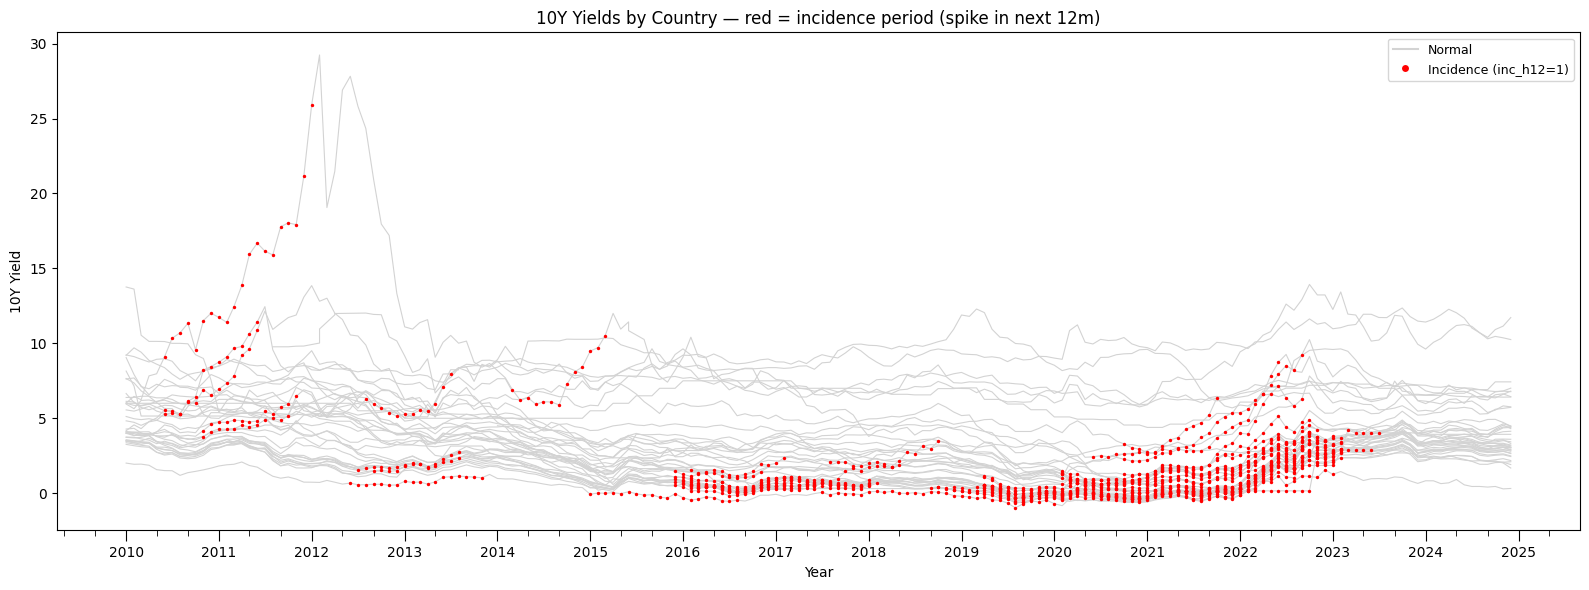

In [57]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import pandas as pd

fig, ax = plt.subplots(figsize=(16, 6))

for isocode, group in df.groupby(level='isocode'):
    periods = group.index.get_level_values('period')
    dates = pd.to_datetime(periods.astype(str), format='%Y%m')
    yields = group['yield_10y']

    ax.plot(dates, yields, color='lightgrey', linewidth=0.8, zorder=1)

    mask = group['inc_h12'] == 1
    ax.scatter(dates[mask], yields[mask], color='red', s=6, zorder=2, linewidths=0)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[5, 9]))
ax.tick_params(axis='x', which='minor', length=4)
ax.tick_params(axis='x', which='major', length=8)

ax.set_xlabel('Year')
ax.set_ylabel('10Y Yield')
ax.set_title('10Y Yields by Country — red = incidence period (spike in next 12m)')

legend_elements = [
    Line2D([0], [0], color='lightgrey', linewidth=1.5, label='Normal'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=6, label='Incidence (inc_h12=1)')
]
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.show()


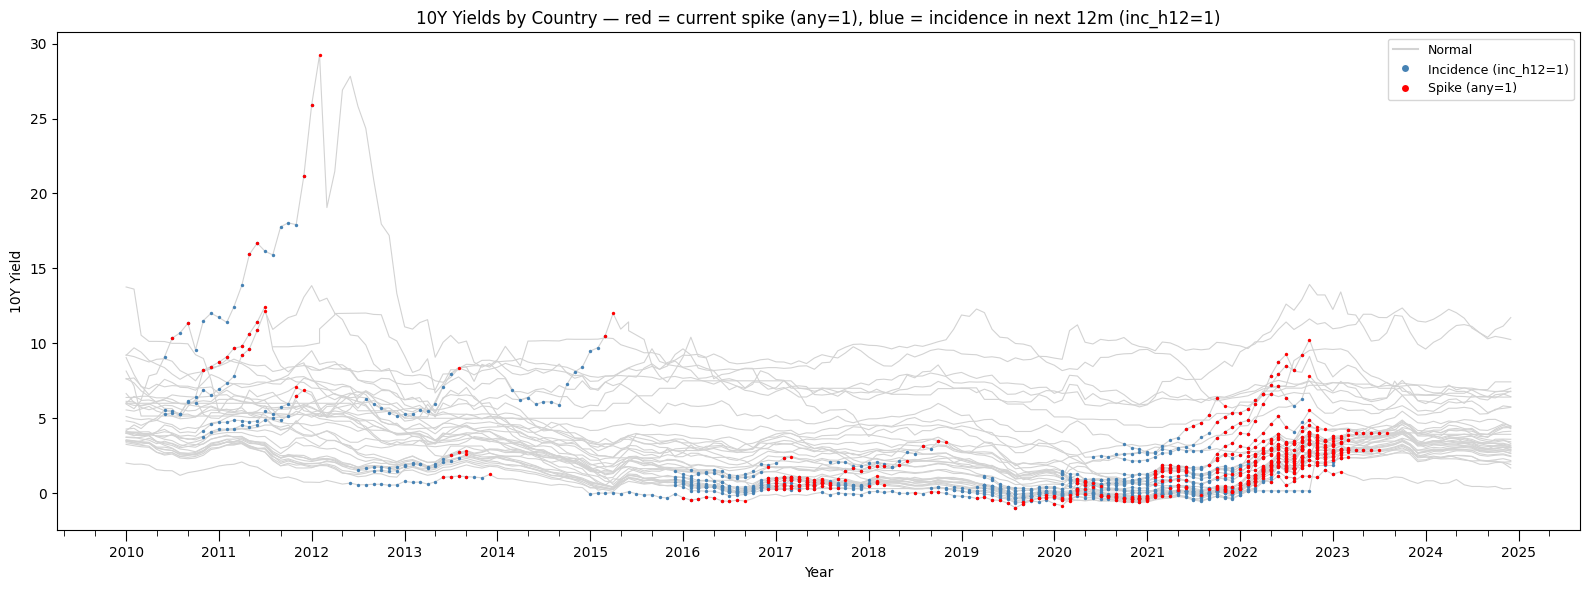

In [59]:
fig, ax = plt.subplots(figsize=(16, 6))

for isocode, group in df.groupby(level='isocode'):
    periods = group.index.get_level_values('period')
    dates = pd.to_datetime(periods.astype(str), format='%Y%m')
    yields = group['yield_10y']

    ax.plot(dates, yields, color='lightgrey', linewidth=0.8, zorder=1)

    mask_inc = group['inc_h12'] == 1
    ax.scatter(dates[mask_inc], yields[mask_inc], color='steelblue', s=6, zorder=2, linewidths=0)

    mask_any = group['any'] == 1
    ax.scatter(dates[mask_any], yields[mask_any], color='red', s=6, zorder=3, linewidths=0)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[5, 9]))
ax.tick_params(axis='x', which='minor', length=4)
ax.tick_params(axis='x', which='major', length=8)

ax.set_xlabel('Year')
ax.set_ylabel('10Y Yield')
ax.set_title('10Y Yields by Country — red = current spike (any=1), blue = incidence in next 12m (inc_h12=1)')

legend_elements = [
    Line2D([0], [0], color='lightgrey', linewidth=1.5, label='Normal'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue', markersize=6, label='Incidence (inc_h12=1)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=6, label='Spike (any=1)'),
]
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.show()


#### Table of onset for different horizons

In [25]:
ons_display = df[cols + ons_cols].reset_index().round(2)
ons_display


,isocode,period,yield_10y,trailing_mean_12m,dev_from_mean_12m,any,ons_h12
0,AUS,201001,5.56,NaN,NaN,NaN,NaN
1,AUS,201002,5.48,NaN,NaN,NaN,NaN
2,AUS,201003,5.62,NaN,NaN,NaN,NaN
3,AUS,201004,5.80,NaN,NaN,NaN,NaN
4,AUS,201005,5.48,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
6928,ZAF,202408,10.70,11.78,-0.09,0.0,NaN
6929,ZAF,202409,10.30,11.70,-0.12,0.0,NaN
6930,ZAF,202410,10.46,11.55,-0.09,0.0,NaN
6931,ZAF,202411,10.37,11.39,-0.09,0.0,NaN


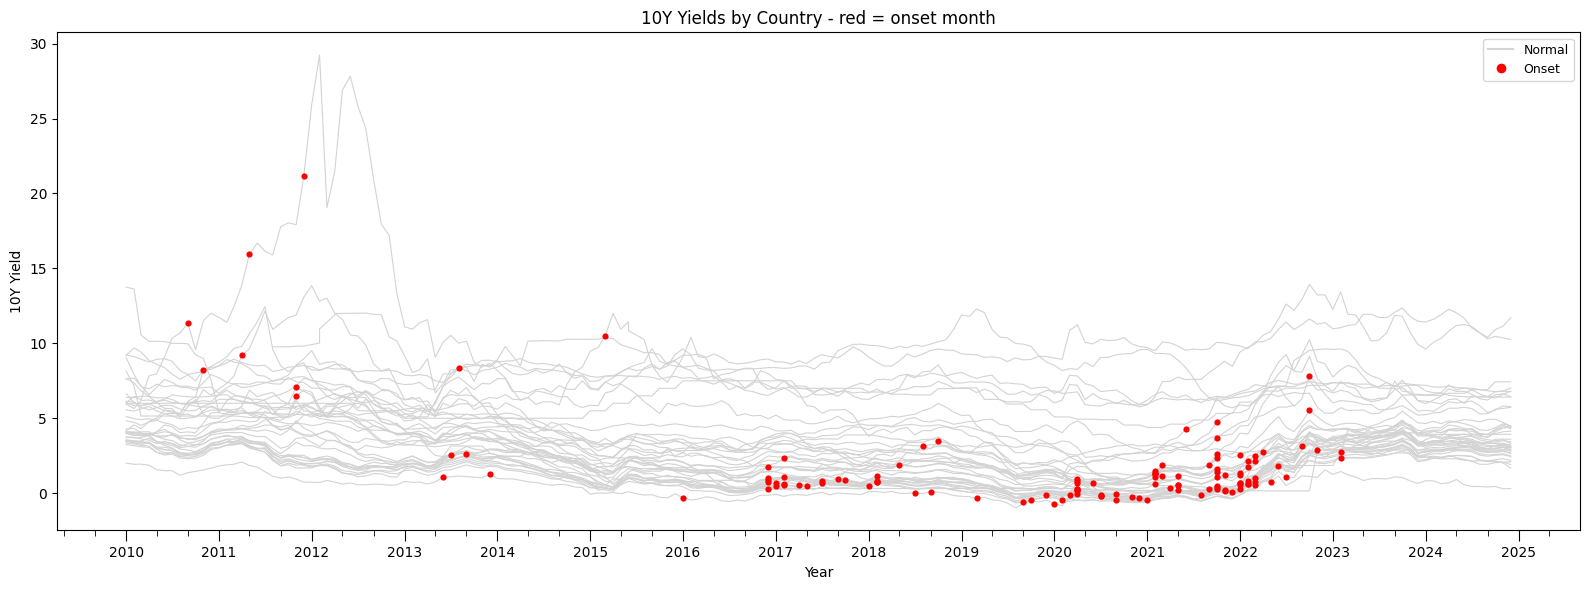

In [64]:
df['spike_start'] = (
    df.groupby(level='isocode')['any']
    .transform(lambda s: (s == 1) & (s.shift(1) == 0))
).astype(float)

fig, ax = plt.subplots(figsize=(16, 6))

for isocode, group in df.groupby(level='isocode'):
    periods = group.index.get_level_values('period')
    dates = pd.to_datetime(periods.astype(str), format='%Y%m')
    yields = group['yield_10y']

    ax.plot(dates, yields, color='lightgrey', linewidth=0.8, zorder=1)

    mask = group['spike_start'] == 1
    ax.scatter(dates[mask], yields[mask], color='red', s=20, zorder=3, linewidths=0)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[5, 9]))
ax.tick_params(axis='x', which='minor', length=4)
ax.tick_params(axis='x', which='major', length=8)

ax.set_xlabel('Year')
ax.set_ylabel('10Y Yield')
ax.set_title('10Y Yields by Country - red = onset month')

legend_elements = [
    Line2D([0], [0], color='lightgrey', linewidth=1.5, label='Normal'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Onset'),
]
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.show()


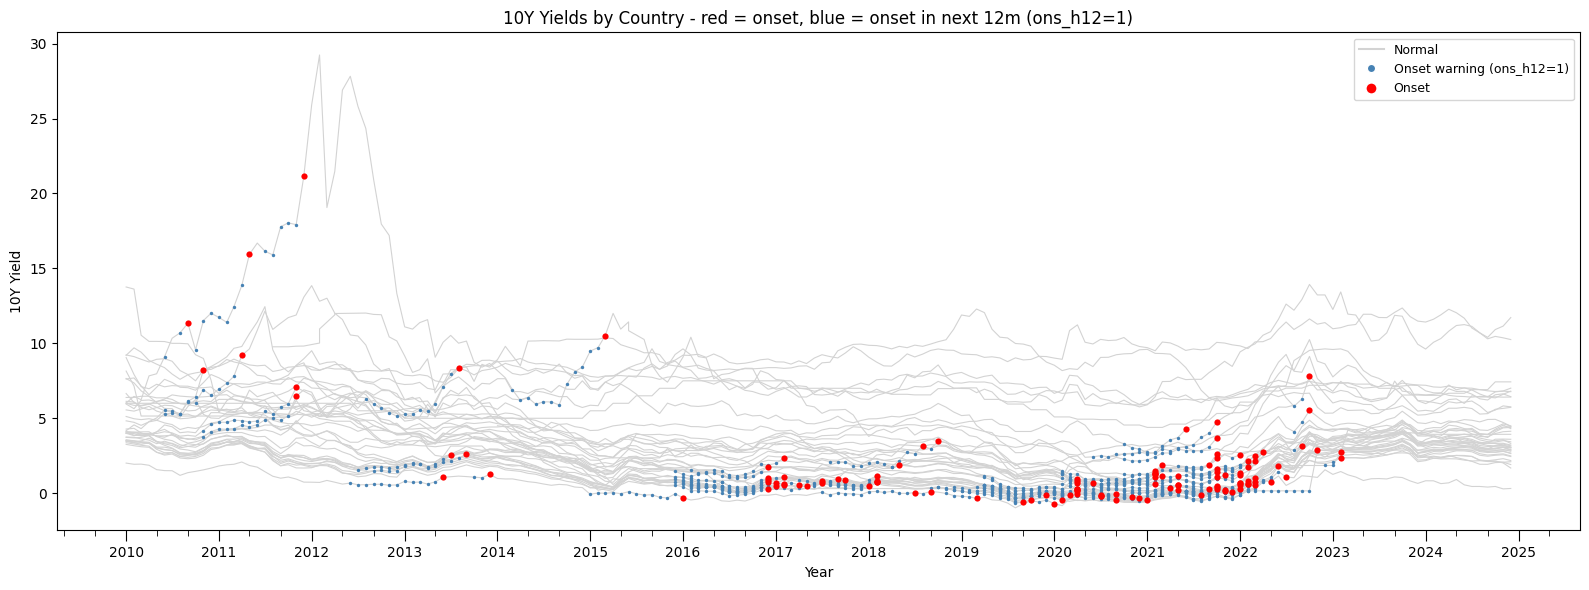

In [65]:
fig, ax = plt.subplots(figsize=(16, 6))

for isocode, group in df.groupby(level='isocode'):
    periods = group.index.get_level_values('period')
    dates = pd.to_datetime(periods.astype(str), format='%Y%m')
    yields = group['yield_10y']

    ax.plot(dates, yields, color='lightgrey', linewidth=0.8, zorder=1)

    mask_ons = group['ons_h12'] == 1
    ax.scatter(dates[mask_ons], yields[mask_ons], color='steelblue', s=6, zorder=2, linewidths=0)

    mask_start = group['spike_start'] == 1
    ax.scatter(dates[mask_start], yields[mask_start], color='red', s=20, zorder=3, linewidths=0)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[5, 9]))
ax.tick_params(axis='x', which='minor', length=4)
ax.tick_params(axis='x', which='major', length=8)

ax.set_xlabel('Year')
ax.set_ylabel('10Y Yield')
ax.set_title('10Y Yields by Country - red = onset, blue = onset in next 12m (ons_h12=1)')

legend_elements = [
    Line2D([0], [0], color='lightgrey', linewidth=1.5, label='Normal'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue', markersize=6, label='Onset warning (ons_h12=1)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Onset'),
]
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.show()


## Feature Engineering

We build three groups of features from the yield data, following the structure from the class notebooks.

**Yield history features** capture the level and trajectory of each country's 10-year bond yield:
- **Rolling means** over 3, 6, 12 - smoothed yield level at different time scales
- **Rolling std** over 3, 6, 12 - rolling standard deviation of the yield level, instability

**Spike state features** encode where we currently are in the spike cycle:
- **`since_spike`** — months since the last spike (i.e. since `any==1`), following the class `since` definition
- **`ongoing_spike`** — consecutive months the current spike has been running, following the class `ongoing` definition

**Text and macro features** (full model only):
- **Stock and Flows** - for Politics, Poltical Tensions and Economics
- **Macro variables** - Inflation, Oil, lag Oil

We define two feature sets: a **baseline** (yield features only) and a **full** model (yield + macro + text), allowing us to isolate the marginal contribution of each data source.


In [26]:
g = df.groupby(level='isocode')

for w in [3, 6, 12]:
    df[f'yield_roll_mean_{w}m'] = g['yield_10y'].transform(
        lambda s, w=w: s.rolling(w, min_periods=1).mean()
    )
    df[f'yield_roll_std_{w}m'] = g['yield_10y'].transform(
        lambda s, w=w: s.rolling(w, min_periods=2).std()
    )

df[['yield_10y'] + [c for c in df.columns if 'roll' in c]].reset_index().round(2)


,isocode,period,yield_10y,yield_roll_mean_3m,yield_roll_std_3m,yield_roll_mean_6m,yield_roll_std_6m,yield_roll_mean_12m,yield_roll_std_12m
0,AUS,201001,5.56,5.56,NaN,5.56,NaN,5.56,NaN
1,AUS,201002,5.48,5.52,0.06,5.52,0.06,5.52,0.06
2,AUS,201003,5.62,5.55,0.07,5.55,0.07,5.55,0.07
3,AUS,201004,5.80,5.63,0.16,5.61,0.13,5.61,0.13
4,AUS,201005,5.48,5.63,0.16,5.59,0.13,5.59,0.13
...,...,...,...,...,...,...,...,...,...
6928,ZAF,202408,10.70,11.13,0.50,11.60,0.62,11.70,0.49
6929,ZAF,202409,10.30,10.67,0.36,11.34,0.78,11.55,0.62
6930,ZAF,202410,10.46,10.49,0.20,11.03,0.69,11.39,0.63
6931,ZAF,202411,10.37,10.38,0.08,10.76,0.52,11.27,0.68


#### Spike state features

In [27]:
def count_since(x):
    x = list(x)
    y = []
    for n in range(len(x)):
        if x[n] == 1:
            y.append(0)
        elif n == 0:
            y.append(1)
        else:
            y.append(y[n-1] + 1)
    return y

def count_ongoing(x):
    x = list(x)
    y, ctr = [], 0
    for n in range(len(x)):
        if x[n] == 1:
            ctr += 1
            y.append(ctr)
        else:
            ctr = 0
            y.append(0)
    return y

any_binary = df['any'].fillna(0).astype(int)
df['since_spike'] = any_binary.groupby(level='isocode').transform(count_since)
df['ongoing_spike'] = any_binary.groupby(level='isocode').transform(count_ongoing)

df[['any', 'since_spike', 'ongoing_spike']].reset_index().round(2)


,isocode,period,any,since_spike,ongoing_spike
0,AUS,201001,NaN,1,0
1,AUS,201002,NaN,2,0
2,AUS,201003,NaN,3,0
3,AUS,201004,NaN,4,0
4,AUS,201005,NaN,5,0
...,...,...,...,...,...
6928,ZAF,202408,0.0,176,0
6929,ZAF,202409,0.0,177,0
6930,ZAF,202410,0.0,178,0
6931,ZAF,202411,0.0,179,0


#### Text and Macro Features w/ Topic/Stock Flows

In [28]:
topic_cols = [
    'Politics',
    'Political Tensions',
    'Economics'
]

delta = 0.8
for topic in topic_cols:
    def compute_stock(series):
        stock = 0.0
        stocks = []
        for val in series:
            stock = delta * stock + (val if pd.notna(val) else 0)
            stocks.append(stock)
        return stocks
    df[f'{topic}_stock'] = df.groupby(level='isocode')[topic].transform(compute_stock)

stock_cols = [f'{t}_stock' for t in topic_cols]

df['brent_oil_lag1'] = df.groupby(level='isocode')['brent_oil'].shift(1)

macro_cols = ['inflation', 'brent_oil', 'brent_oil_lag1']

missing = [c for c in topic_cols + stock_cols + macro_cols if c not in df.columns]
print("Missing columns:", missing if missing else "None")


Missing columns: None


## Modelling

We generate pseudo-out-of-sample predictions using an expanding window approach, following the rolling forecast structure from the class notebooks (Ben's PanelSplit implementation).

**Setup:**
- Test period starts at **202301**, generating one prediction per month up to the end of the sample (`test_size=1`)
- For each horizon h, we set `gap=h` in PanelSplit to prevent leakage — this ensures the training set never includes target values that overlap with the forecast window
- We use a **Random Forest classifier** with the default class specification: `max_depth=4`, `max_features=0.2`, `min_samples_leaf=100`

**Models:**
For h = 12, run full model

This gives 16 models in total (4 horizons × 2 targets × 2 feature sets), all evaluated pseudo-out-of-sample.


Def feature set

In [33]:
full_cols = baseline_cols + topic_cols + stock_cols + macro_cols
print(f"Full features:     {len(full_cols)}")


Full features:     18


set up panel split

In [34]:
TEST_START = 202301
row_periods = df.index.get_level_values('period').tolist()
unique_periods = sorted(set(row_periods))

def build_cv(gap, test_size=1):
    test_start_idx = unique_periods.index(TEST_START)
    n_splits = len(unique_periods) - test_start_idx
    return PanelSplit(
        periods=row_periods,
        n_splits=n_splits,
        test_size=test_size,
        gap=gap
    )

cv = build_cv(gap=11)
print(f"Horizon 12m: {cv.n_splits} splits, gap=11")




Horizon 12m: 24 splits, gap=11


Run models

In [38]:
from sklearn.ensemble import RandomForestClassifier
from panelsplit.application import cross_val_fit_predict

rf = RandomForestClassifier(max_depth=4, max_features=0.2, min_samples_leaf=100, random_state=42)

cv = build_cv(gap=11)
results = {}

for target_name, target_col in [('incidence', 'inc_h12'), ('onset', 'ons_h12')]:
    for model_name, feat_cols in [('baseline', baseline_cols), ('full', full_cols)]:
        X = df[feat_cols]
        y = df[target_col].astype(float)

        preds, _ = cross_val_fit_predict(
            estimator=rf,
            X=X,
            y=y,
            cv=cv,
            method='predict_proba',
            drop_na_in_y=True
        )

        final_df = cv.gen_test_labels(
            df[[target_col]].rename(columns={target_col: 'y_true'})
        )
        final_df['pred_prob'] = preds[:, 1]
        final_df['horizon'] = 12
        final_df['model'] = model_name
        final_df['target'] = target_name

        results[(target_name, model_name)] = final_df
        print(f"Done: target={target_name}  model={model_name}")

print("\nAll done.")


Done: target=incidence  model=baseline
Done: target=incidence  model=full
Done: target=onset  model=baseline
Done: target=onset  model=full

All done.


Plot curves

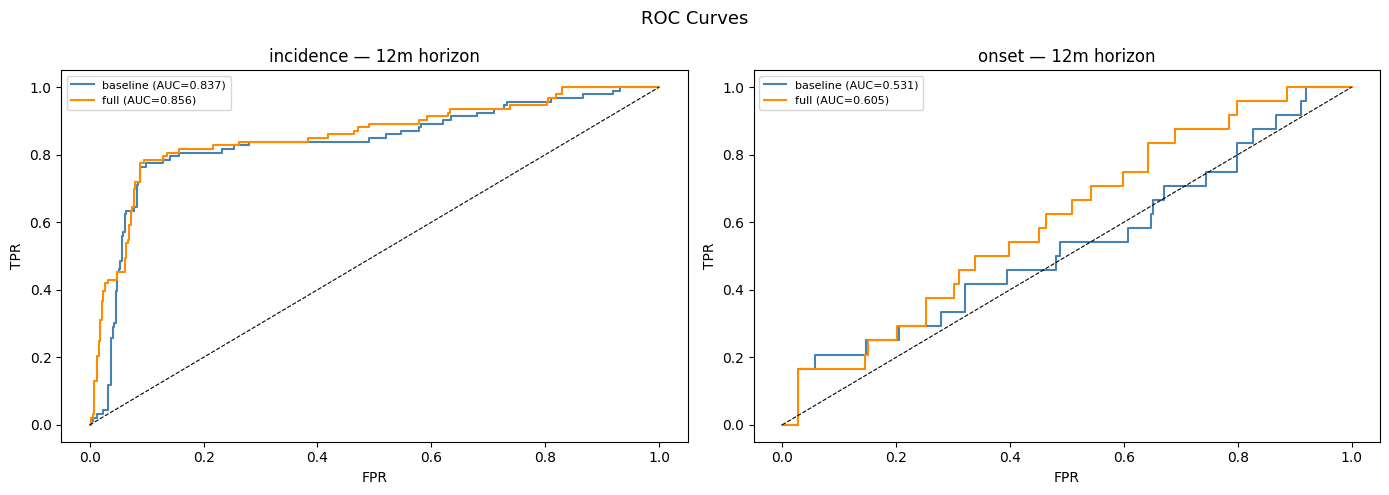

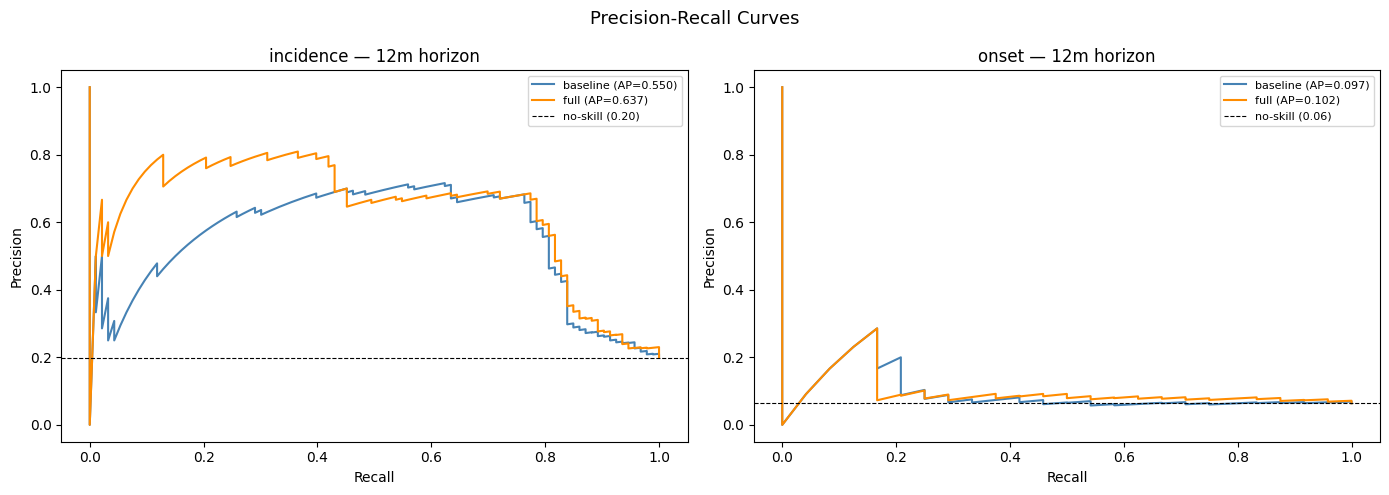

In [39]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

model_styles = [('baseline', 'steelblue'), ('full', 'darkorange')]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for target_name, ax in [('incidence', axes[0]), ('onset', axes[1])]:
    for model_name, color in model_styles:
        df_res = results[(target_name, model_name)].dropna(subset=['y_true', 'pred_prob'])
        y_true = df_res['y_true'].astype(float)
        y_pred = df_res['pred_prob']

        fpr, tpr, _ = roc_curve(y_true, y_pred)
        auc = roc_auc_score(y_true, y_pred)
        ax.plot(fpr, tpr, color=color, label=f'{model_name} (AUC={auc:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
    ax.set_title(f'{target_name} — 12m horizon')
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.legend(fontsize=8)

plt.suptitle('ROC Curves', fontsize=13)
plt.tight_layout()
plt.show()

# Precision-Recall
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for target_name, ax in [('incidence', axes[0]), ('onset', axes[1])]:
    for model_name, color in model_styles:
        df_res = results[(target_name, model_name)].dropna(subset=['y_true', 'pred_prob'])
        y_true = df_res['y_true'].astype(float)
        y_pred = df_res['pred_prob']

        precision, recall, _ = precision_recall_curve(y_true, y_pred)
        ap = average_precision_score(y_true, y_pred)
        ax.plot(recall, precision, color=color, label=f'{model_name} (AP={ap:.3f})')

    baseline_rate = y_true.mean()
    ax.axhline(baseline_rate, color='k', linestyle='--', linewidth=0.8, label=f'no-skill ({baseline_rate:.2f})')
    ax.set_title(f'{target_name} — 12m horizon')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.legend(fontsize=8)

plt.suptitle('Precision-Recall Curves', fontsize=13)
plt.tight_layout()
plt.show()


BONUS: Adapt the cost model to your purpose. Use it to find the optimal cut-off under
assumptions on the costs on TP, FP, TN and FN. In order to argue for the reasonability of

your assumptions it will help to think of what FP and FN in particular mean for your decision-
maker from question 3). (10 pts)

incidence | C_FP:C_FN = 1:3 (miss spike costly): threshold=0.340  TPR=0.774  FPR=0.088
incidence | C_FP:C_FN = 1.5:1 (false alarm costly): threshold=0.535  TPR=0.419  FPR=0.027
onset | C_FP:C_FN = 1:3 (miss spike costly): threshold=0.206  TPR=0.167  FPR=0.028
onset | C_FP:C_FN = 1.5:1 (false alarm costly): threshold=inf  TPR=0.000  FPR=0.000


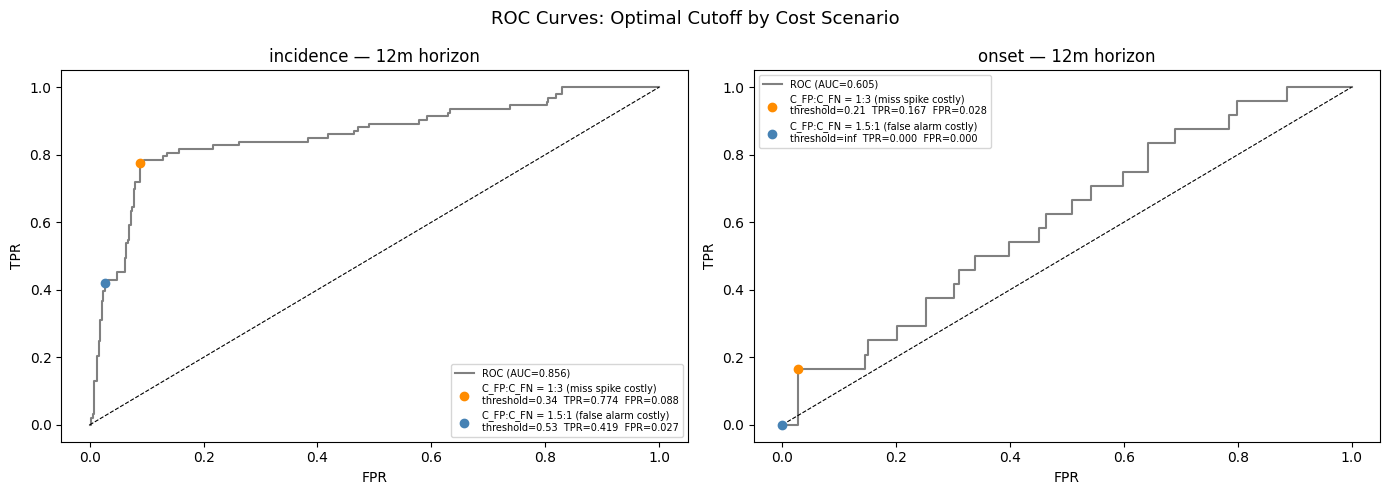

In [45]:
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score

scenarios = [
    {'C_FP': 1, 'C_FN': 3, 'label': 'C_FP:C_FN = 1:3 (miss spike costly)', 'color': 'darkorange'},
    {'C_FP': 1.5, 'C_FN': 1, 'label': 'C_FP:C_FN = 1.5:1 (false alarm costly)', 'color': 'steelblue'},
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for target_name, ax in [('incidence', axes[0]), ('onset', axes[1])]:
    df_res = results[(target_name, 'full')].dropna(subset=['y_true', 'pred_prob'])
    y_true = df_res['y_true'].astype(float)
    y_pred = df_res['pred_prob']
    prevalence = y_true.mean()

    fpr, tpr, thresholds = roc_curve(y_true, y_pred)
    ax.plot(fpr, tpr, color='grey', linewidth=1.5, label=f'ROC (AUC={roc_auc_score(y_true, y_pred):.3f})')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)

    for s in scenarios:
        fnr = 1 - tpr
        cost = s['C_FP'] * fpr * (1 - prevalence) + s['C_FN'] * fnr * prevalence
        idx = np.argmin(cost)
        ax.scatter(fpr[idx], tpr[idx], color=s['color'], zorder=5,
                   label=f"{s['label']}\nthreshold={thresholds[idx]:.2f}  TPR={tpr[idx]:.3f}  FPR={fpr[idx]:.3f}")
        print(f"{target_name} | {s['label']}: threshold={thresholds[idx]:.3f}  TPR={tpr[idx]:.3f}  FPR={fpr[idx]:.3f}")

    ax.set_title(f'{target_name} — 12m horizon')
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.legend(fontsize=7)

plt.suptitle('ROC Curves: Optimal Cutoff by Cost Scenario', fontsize=13)
plt.tight_layout()
plt.show()


## Bonus: Cost-Sensitive Optimal Cutoff

Our decision-maker is an international policy institution such as the IMF, whose mandate includes early identification of sovereign debt stress to pre-position emergency lending facilities. In this context, the costs of classification errors are asymmetric.

### Defining Error Costs

A **false negative (FN)** — failing to flag a country that subsequently experiences a yield spike — means the institution enters a crisis reactively. Consequences include delayed disbursement, larger required intervention, heightened contagion risk, and significant human cost from the fiscal adjustment that accompanies crisis-mode lending.

A **false positive (FP)** — flagging a country that does not spike — risks triggering precautionary engagement with reputational and signalling costs. Even where the facility is non-public (e.g. the IMF Flexible Credit Line), internal resources are misallocated and political capital is spent unnecessarily. In extreme cases, a public signal of IMF engagement can itself destabilise market confidence — a self-fulfilling prophecy that manufactures the stress it sought to prevent.

### Cost Scenarios

We evaluate two scenarios to bound the analysis:

| Scenario | C_FP | C_FN | Interpretation |
|----------|------|------|----------------|
| 1 | 1 | 3 | Missing a spike is 3× more costly — delayed crisis response dominates |
| 2 | 1.5 | 1 | False alarms are more costly — stigma and signalling risk dominate |

### Results

**Incidence model** (will a spike occur in the next 12 months?):

| Scenario | Threshold | TPR | FPR |
|----------|-----------|-----|-----|
| C_FP:C_FN = 1:3 | 0.34 | 77.4% | 8.8% |
| C_FP:C_FN = 1.5:1 | 0.54 | 41.9% | 2.7% |

Under Scenario 1, the model flags 3 in 4 real stress episodes with few false alarms — a strong operating point for early warning. Under Scenario 2, the threshold rises above 0.5, sacrificing recall sharply to minimise unnecessary interventions.

**Onset model** (will a *new* spike begin in the next 12 months?):

| Scenario | Threshold | TPR | FPR |
|----------|-----------|-----|-----|
| C_FP:C_FN = 1:3 | 0.21 | 16.7% | 2.8% |
| C_FP:C_FN = 1.5:1 | ∞ | 0.0% | 0.0% |

The onset model is not decision-useful under either cost scenario. Under Scenario 2, the cost-minimising policy is to never intervene — the model's discriminative power (AUC=0.605) is insufficient to justify action when false alarms are costly. Under Scenario 1 it flags at a very low threshold but still recovers fewer than 1 in 5 true onsets.

### Conclusion

The **incidence model under Scenario 1** represents the most actionable configuration: threshold=0.34, TPR=77.4%, FPR=8.8%. This is consistent with an IMF mandate that prioritises early response over conservatism. The onset model requires richer forward-looking features — the NLP variables improve AUC from 0.531 to 0.605 relative to the baseline, but are not yet sufficient for cost-effective early warning of new stress episodes.
